In [7]:
pip install pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.3/336.3 kB 6.2 MB/s eta 0:00:00


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re


In [5]:
from google.colab import files
uploaded = files.upload()

Saving Gadsby.pdf to Gadsby (1).pdf


In [9]:
from pypdf import PdfReader
reader = PdfReader("Gadsby.pdf")
f = open("Gadsby.txt", "w")
f.write("Gadsby by Ernest Vincent Wright\n")
for page in reader.pages[4:]:
    f.write(page.extract_text())
f.close()


In [10]:
import csv
file = open("Gadsby.txt", "r")
writer = csv.writer(open("Gadsby.csv", "w"))
for line in file:
    writer.writerow([line])
file.close()

In [11]:
import pandas as pd
df = pd.read_csv("Gadsby.csv", header=None)
df.drop(df.index[0], inplace=True)
df.reset_index(drop=True, inplace=True)

/tmp/ipykernel_5180/4157326597.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_lengths, x='Length', y='Count', ax=axes[0, 0], palette="viridis")
/tmp/ipykernel_5180/4157326597.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_letters, x='Letter', y='Count', ax=axes[1, 0], palette="crest")
/tmp/ipykernel_5180/4157326597.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_longest, y='Word', x='Frequency', ax=axes[1, 1], palette="magma")


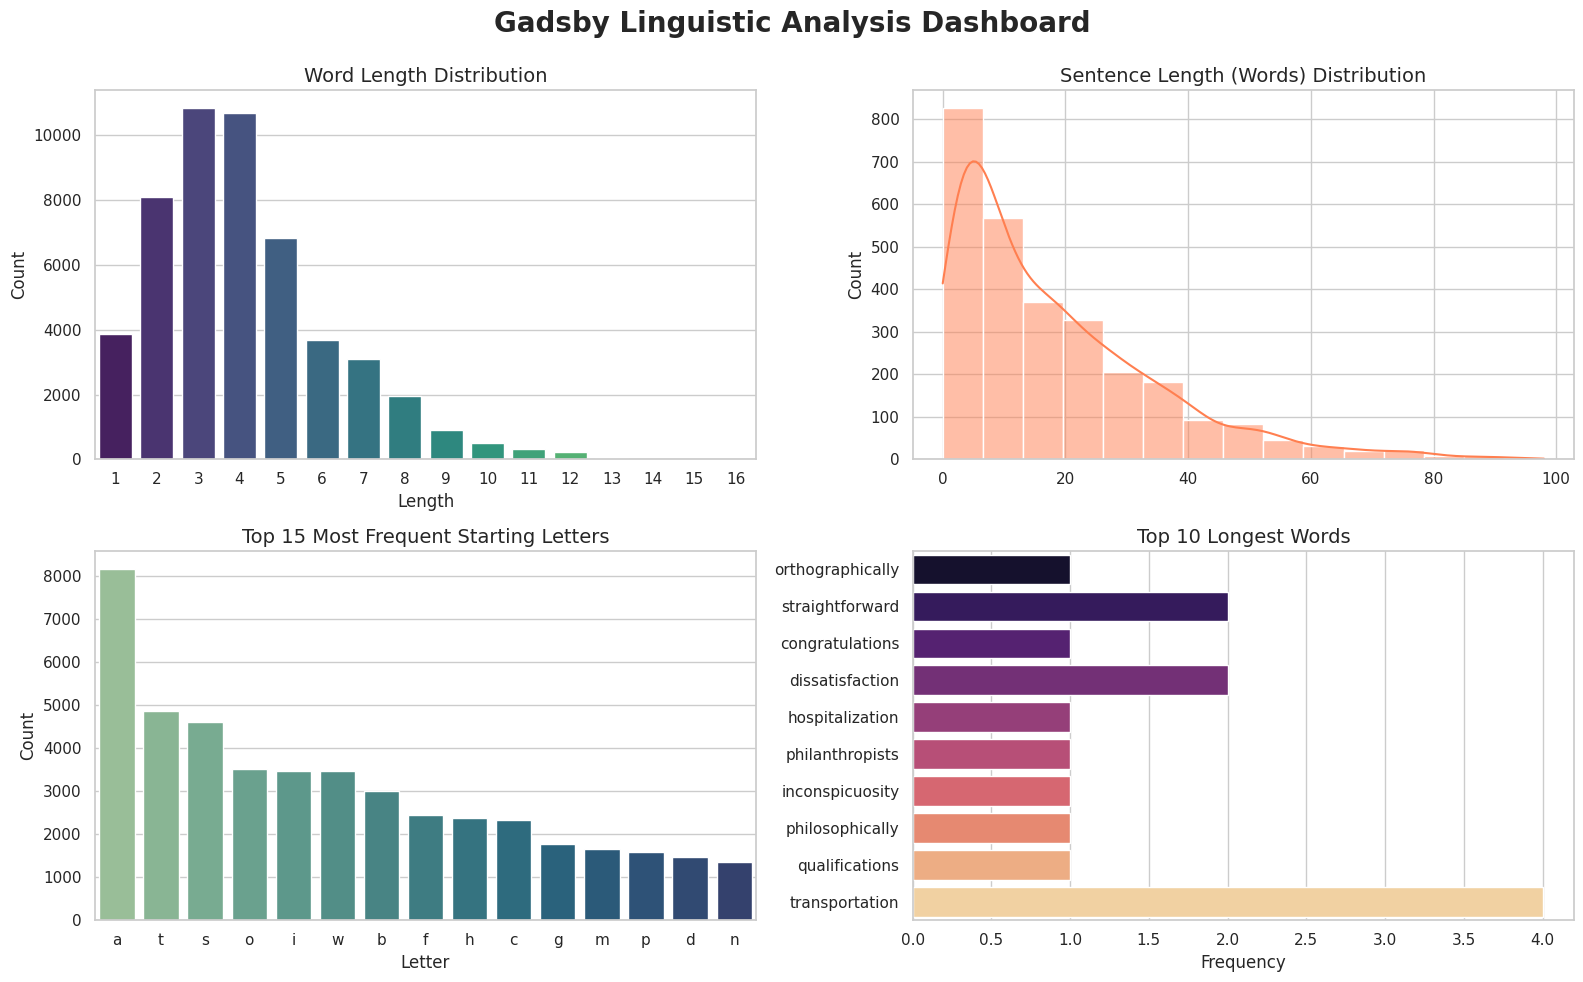

In [12]:
raw_text = " ".join(df[0].tolist())

# Clean and tokenize
sentences = [s.strip() for s in re.split(r'[.!?]+', raw_text) if len(s.strip()) > 0]
tokens = re.findall(r'\b[a-zA-Z]+\b', raw_text)
clean_tokens = [word.lower() for word in tokens]

# --- METRICS CALCULATION ---
# 1. Word Lengths
word_lengths = [len(word) for word in clean_tokens]
df_lengths = pd.DataFrame(list(Counter(word_lengths).items()), columns=['Length', 'Count']).sort_values('Length')

# 2. Sentence Lengths
sentence_lengths = [len(re.findall(r'\b[a-zA-Z]+\b', sent)) for sent in sentences]

# 3. Starting Letters
df_letters = pd.DataFrame(list(Counter([word[0] for word in clean_tokens]).items()),
                          columns=['Letter', 'Count']).sort_values('Count', ascending=False).head(15)

# 4. Top 10 Longest Words
unique_words = list(set(clean_tokens))
unique_words.sort(key=len, reverse=True)
top_longest = unique_words[:10]
df_longest = pd.DataFrame({'Word': top_longest, 'Frequency': [clean_tokens.count(w) for w in top_longest]})

# --- DASHBOARD PLOTTING ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Gadsby Linguistic Analysis Dashboard", fontsize=20, fontweight='bold')

# Plot 1: Word Length Distribution
sns.barplot(data=df_lengths, x='Length', y='Count', ax=axes[0, 0], palette="viridis")
axes[0, 0].set_title("Word Length Distribution", fontsize=14)

# Plot 2: Sentence Length Distribution
sns.histplot(sentence_lengths, bins=15, ax=axes[0, 1], color="coral", kde=True)
axes[0, 1].set_title("Sentence Length (Words) Distribution", fontsize=14)

# Plot 3: Most Frequent Starting Letters
sns.barplot(data=df_letters, x='Letter', y='Count', ax=axes[1, 0], palette="crest")
axes[1, 0].set_title("Top 15 Most Frequent Starting Letters", fontsize=14)

# Plot 4: Top Longest Words
sns.barplot(data=df_longest, y='Word', x='Frequency', ax=axes[1, 1], palette="magma")
axes[1, 1].set_title("Top 10 Longest Words", fontsize=14)
axes[1, 1].set_ylabel("")

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()